In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

#Wczytanie plików CSV 
train_df = pd.read_csv('train.csv', low_memory=False)
store_df = pd.read_csv('store.csv')

df = pd.merge(train_df, store_df, on='Store', how='left')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date').reset_index(drop=True)

print(f"Liczba wierszy (transakcji): {df.shape[0]}")
print(f"Liczba kolumn (zmiennych): {df.shape[1]}")

Liczba wierszy (transakcji): 1017209
Liczba kolumn (zmiennych): 18


CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64


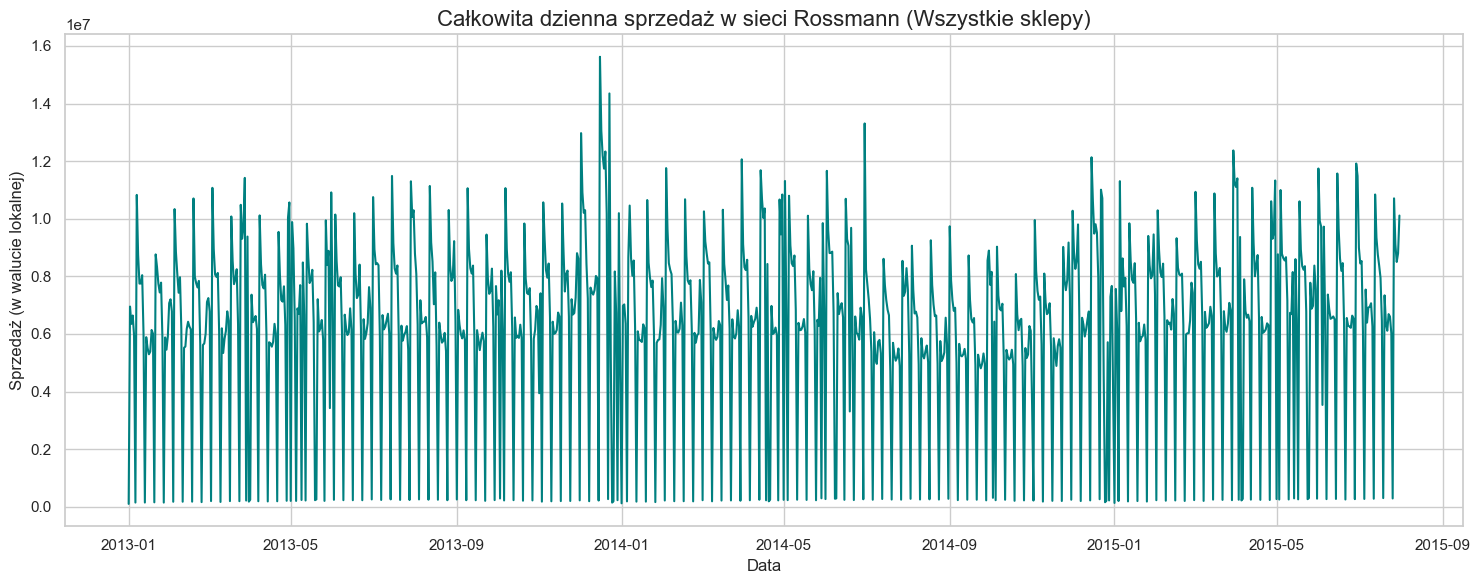

C:\Users\kpapr\AppData\Local\Temp\ipykernel_23996\2532970816.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DayOfWeek', y='Sales', data=df_open, ax=axes[0], palette="Blues_d")
C:\Users\kpapr\AppData\Local\Temp\ipykernel_23996\2532970816.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Promo', y='Sales', data=df_open, ax=axes[1], palette="Set2")


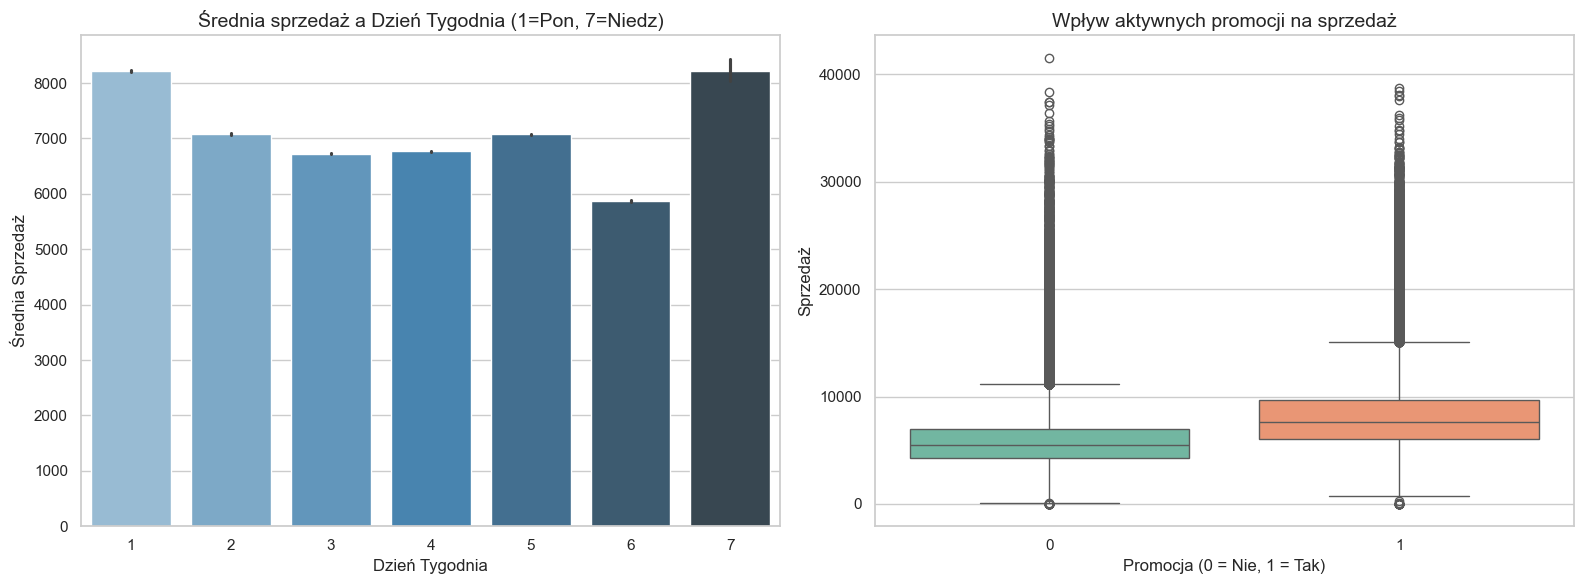

In [21]:
#missing data
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

#wykres głównego trendu
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()

plt.figure(figsize=(15, 6))
plt.plot(daily_sales['Date'], daily_sales['Sales'], color='teal', linewidth=1.5)
plt.title('Całkowita dzienna sprzedaż w sieci Rossmann (Wszystkie sklepy)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Sprzedaż (w walucie lokalnej)', fontsize=12)
plt.tight_layout()
plt.savefig('calkowita_dzienna_sprzedaz.png', dpi=300, bbox_inches='tight')
plt.show()

#analiza sezonowosci i promocji
df_open = df[df['Open'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Wykres 1: Wpływ dnia tygodnia na sprzedaż
sns.barplot(x='DayOfWeek', y='Sales', data=df_open, ax=axes[0], palette="Blues_d")
axes[0].set_title('Średnia sprzedaż a Dzień Tygodnia (1=Pon, 7=Niedz)', fontsize=14)
axes[0].set_xlabel('Dzień Tygodnia')
axes[0].set_ylabel('Średnia Sprzedaż')

# Wykres 2: Wpływ promocji na sprzedaż
sns.boxplot(x='Promo', y='Sales', data=df_open, ax=axes[1], palette="Set2")
axes[1].set_title('Wpływ aktywnych promocji na sprzedaż', fontsize=14)
axes[1].set_xlabel('Promocja (0 = Nie, 1 = Tak)')
axes[1].set_ylabel('Sprzedaż')

plt.tight_layout()
plt.savefig('Wplyw aktywnych promocji na sprzedaz.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# cechy kalendarzowe
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 6 else 0)

#sortowanie
df = df.sort_values(by=['Store', 'Date']).reset_index(drop=True)

#wczorajsza sprzedaż
df['Sales_Lag_1'] = df.groupby('Store')['Sales'].shift(1)
#tygodniowa sprzedaż
df['Sales_Lag_7'] = df.groupby('Store')['Sales'].shift(7)

#średnia dzienan sprzedaż
df['Sales_Rolling_Mean_7'] = df.groupby('Store')['Sales'].transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)

df.dropna(subset=['Sales_Lag_7', 'Sales_Rolling_Mean_7'], inplace=True)

categorical_cols = [col for col in ['StoreType', 'Assortment', 'StateHoliday'] if col in df.columns]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Liczba kolumn przygotowanych dla modelu: {df.shape[1]}")
display(df[['Store', 'Date', 'Sales', 'Sales_Lag_1', 'Sales_Lag_7', 'Sales_Rolling_Mean_7']].head(5))

Liczba kolumn przygotowanych dla modelu: 31


,Store,Date,Sales,Sales_Lag_1,Sales_Lag_7,Sales_Rolling_Mean_7
7,1,2013-01-08,5580,7176.0,0.0,3788.000000
8,1,2013-01-09,5471,5580.0,5530.0,4585.142857
9,1,2013-01-10,4892,5471.0,4327.0,4576.714286
10,1,2013-01-11,4881,4892.0,4486.0,4657.428571
11,1,2013-01-12,4952,4881.0,4997.0,4713.857143


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import time


cols_to_drop = ['Sales', 'Date', 'Customers', 'Store', 'PromoInterval'] 
features = [col for col in df.columns if col not in cols_to_drop]

X = df[features]

X = X.apply(pd.to_numeric, errors='coerce') 

X = X.fillna(0)

y = df['Sales']

split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Dane Treningowe: od {df['Date'].iloc[0].date()} do {df['Date'].iloc[split_index-1].date()} ({len(X_train)} próbek)")
print(f"Dane Testowe: od {df['Date'].iloc[split_index].date()} do {df['Date'].iloc[-1].date()} ({len(X_test)} próbek)\n")

def calculate_wmape(y_true, y_pred):
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))) * 100

results = []

# REGRESJA LINIOWA
# czas
start_czas_lr = time.time()  

lr_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()), 
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
 # koniec czas
koniec_czas_lr = time.time() 
czas_lr_sekundy = koniec_czas_lr - start_czas_lr
print(f"Czas uczenia Regresji Liniowej: {czas_lr_sekundy:.2f} sekund")


lr_preds = np.maximum(lr_pipeline.predict(X_test), 0)

results.append({
    'Model': 'Regresja Liniowa (Baseline)',
    'MAE': mean_absolute_error(y_test, lr_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, lr_preds)),
    'WMAPE (%)': calculate_wmape(y_test, lr_preds)
})

# RANDOM FOREST 
rf_model = RandomForestRegressor(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)


rf_preds = np.maximum(rf_model.predict(X_test), 0)

results.append({
    'Model': 'Random Forest',
    'MAE': mean_absolute_error(y_test, rf_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf_preds)),
    'WMAPE (%)': calculate_wmape(y_test, rf_preds)
})

# XGBOOST
#czas
start_czas_xgb = time.time() 
tscv = TimeSeriesSplit(n_splits=3)

xgb_pipeline = Pipeline(steps=[
    ('model', XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [4, 6],
    'model__learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=2, 
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# koniec czas
koniec_czas_xgb = time.time()
czas_xgb_sekundy = koniec_czas_xgb - start_czas_xgb
minuty = int(czas_xgb_sekundy // 60)
sekundy = int(czas_xgb_sekundy % 60)
print(f"\nCzas optymalizacji XGBoost (GridSearch): {minuty} minut i {sekundy} sekund")

best_xgb = grid_search.best_estimator_
xgb_preds = np.maximum(best_xgb.predict(X_test), 0)

results.append({
    'Model': 'XGBoost (GridSearch)',
    'MAE': mean_absolute_error(y_test, xgb_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, xgb_preds)),
    'WMAPE (%)': calculate_wmape(y_test, xgb_preds)
})



results_df = pd.DataFrame(results)
results_df = results_df.round(2)
display(results_df)


y_pred = xgb_preds

Dane Treningowe: od 2013-01-08 do 2014-01-09 (807523 próbek)
Dane Testowe: od 2014-01-10 do 2015-07-31 (201881 próbek)

Czas uczenia Regresji Liniowej: 1.28 sekund
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Czas optymalizacji XGBoost (GridSearch): 0 minut i 32 sekund


,Model,MAE,RMSE,WMAPE (%)
0,Regresja Liniowa (Baseline),1130.84,1649.60,19.73
1,Random Forest,531.53,875.20,9.28
2,XGBoost (GridSearch),506.87,821.08,8.85


In [24]:
import numpy as np

# Zabezpieczenie typu danych
y_test_array = np.array(y_test)
xgb_preds_array = np.array(xgb_preds)

n_bootstraps = 1000
wmape_scores = []

# Symulacja Bootstrapping (1000 iteracji)
np.random.seed(42)
for i in range(n_bootstraps):
    # Losowanie ze zwracaniem
    indices = np.random.choice(len(y_test_array), len(y_test_array), replace=True)
    y_true_b = y_test_array[indices]
    y_pred_b = xgb_preds_array[indices]
    
    # Obliczanie WMAPE dla danej próbki
    wmape = (np.sum(np.abs(y_true_b - y_pred_b)) / np.sum(np.abs(y_true_b))) * 100
    wmape_scores.append(wmape)

# Obliczenie 95% przedziału ufności
lower_bound = np.percentile(wmape_scores, 2.5)
upper_bound = np.percentile(wmape_scores, 97.5)

print(f"Błąd WMAPE (XGBoost): {calculate_wmape(y_test, xgb_preds):.2f}%")
print(f"95% Przedział ufności (Bootstrapping): [{lower_bound:.2f}%, {upper_bound:.2f}%]")

Błąd WMAPE (XGBoost): 8.85%
95% Przedział ufności (Bootstrapping): [8.80%, 8.89%]


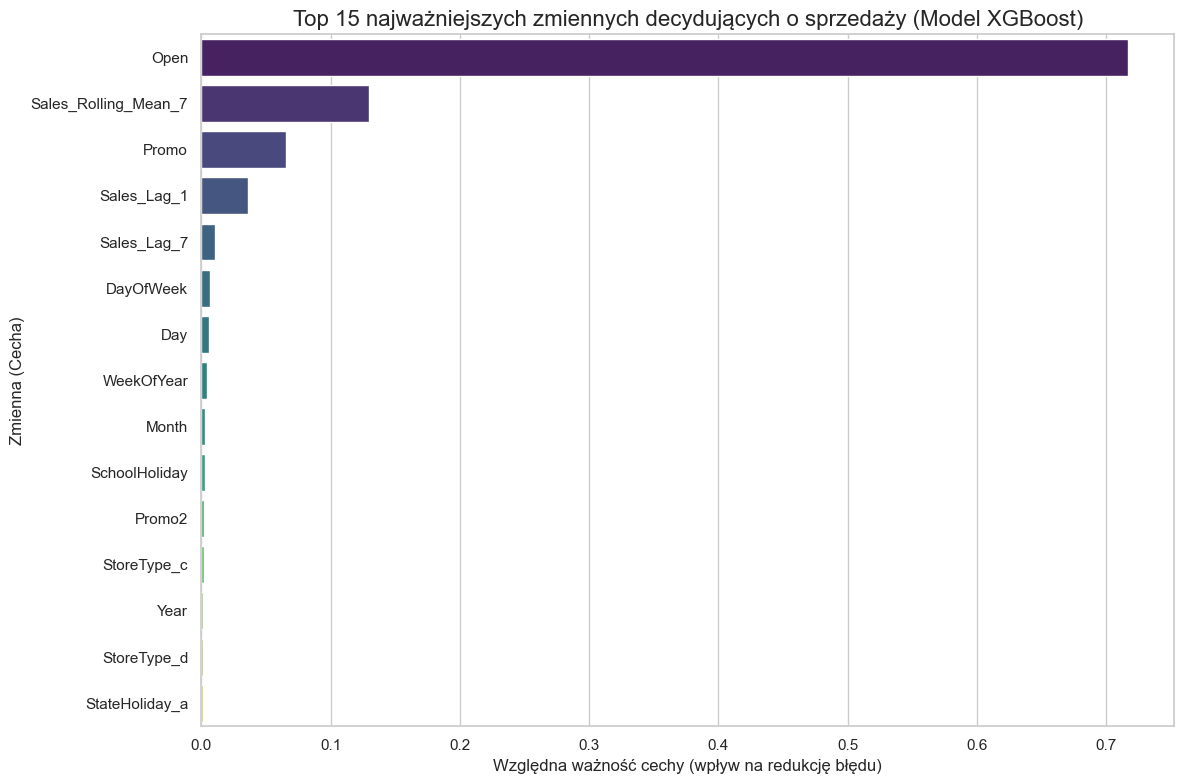

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

actual_model = best_xgb.named_steps['model']
importances = actual_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Cecha': X.columns,
    'Ważność': importances
})

top_features = feature_importance_df.sort_values(by='Ważność', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(
    x='Ważność', 
    y='Cecha', 
    data=top_features, 
    palette='viridis',
    hue='Cecha',
    legend=False
)

plt.title('Top 15 najważniejszych zmiennych decydujących o sprzedaży (Model XGBoost)', fontsize=16)
plt.xlabel('Względna ważność cechy (wpływ na redukcję błędu)', fontsize=12)
plt.ylabel('Zmienna (Cecha)', fontsize=12)
plt.tight_layout()

plt.savefig('Top 15 najważniejszych zmiennych decydujących o sprzedaży (Model XGBoost).png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\kpapr\AppData\Local\Temp\ipykernel_23996\3455113728.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


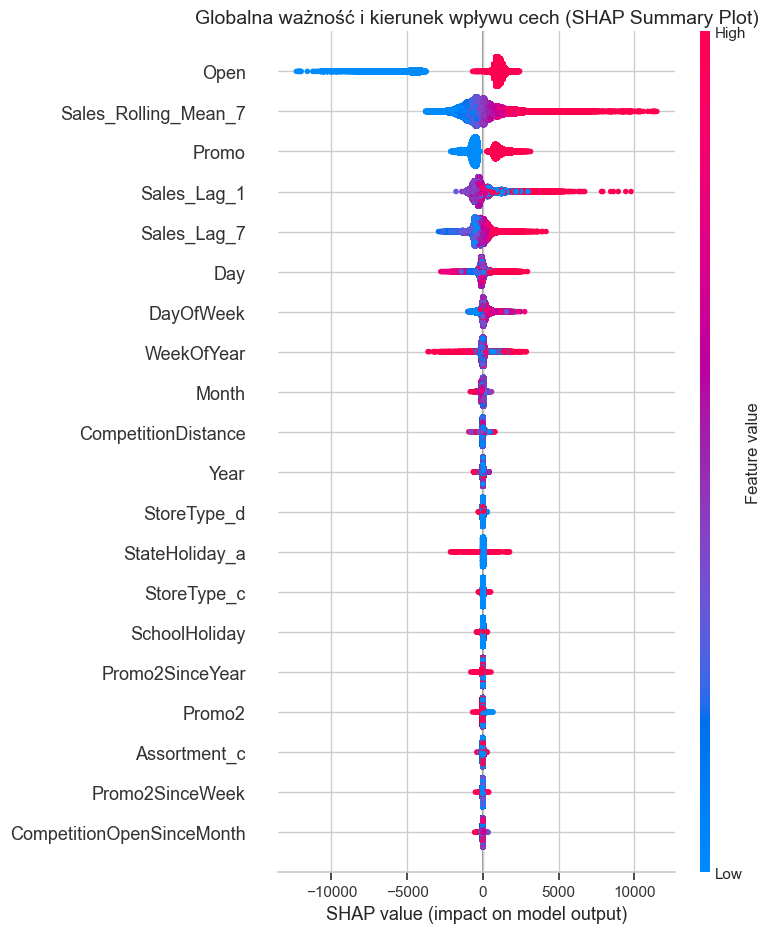

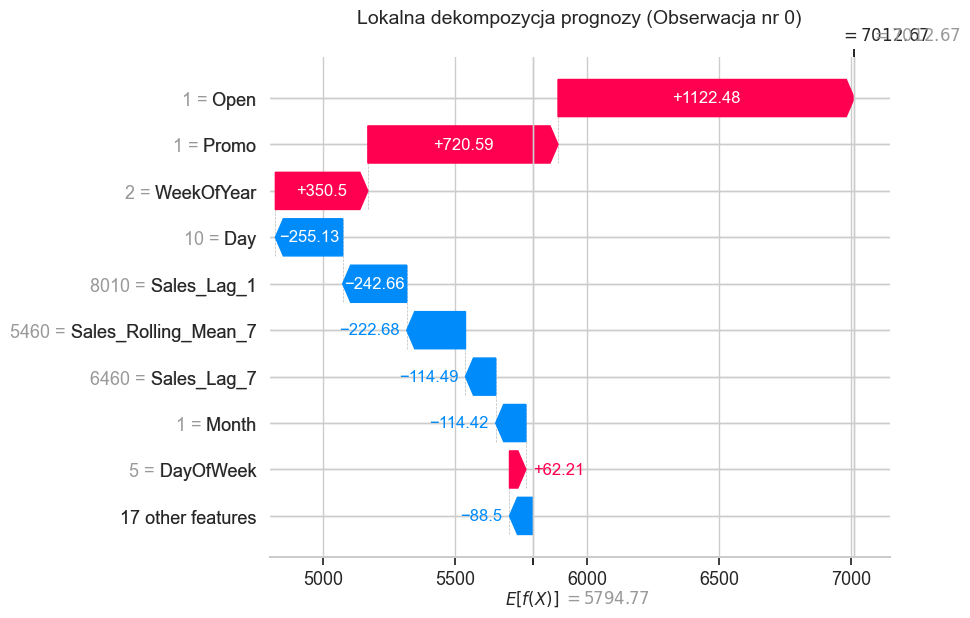

In [26]:
import shap
import matplotlib.pyplot as plt

xgb_model = best_xgb.named_steps['model']
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Globalna ważność i kierunek wpływu cech (SHAP Summary Plot)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300, bbox_inches='tight')
plt.show()

import numpy as np
import copy

plt.close('all') 
plt.clf()

obserwacja_indeks = 0 

zjawisko = copy.deepcopy(shap_values[obserwacja_indeks])

zjawisko.values = np.round(zjawisko.values, 2)
zjawisko.base_values = np.round(zjawisko.base_values, 2)

if isinstance(zjawisko.data, (int, float, np.number)):
    zjawisko.data = np.round(zjawisko.data, 2)


shap.plots.waterfall(zjawisko, show=False)

plt.title(f"Lokalna dekompozycja prognozy (Obserwacja nr {obserwacja_indeks})", fontsize=14, y=1.05)
plt.savefig("shap_waterfall.png", dpi=300, bbox_inches='tight')
plt.show()

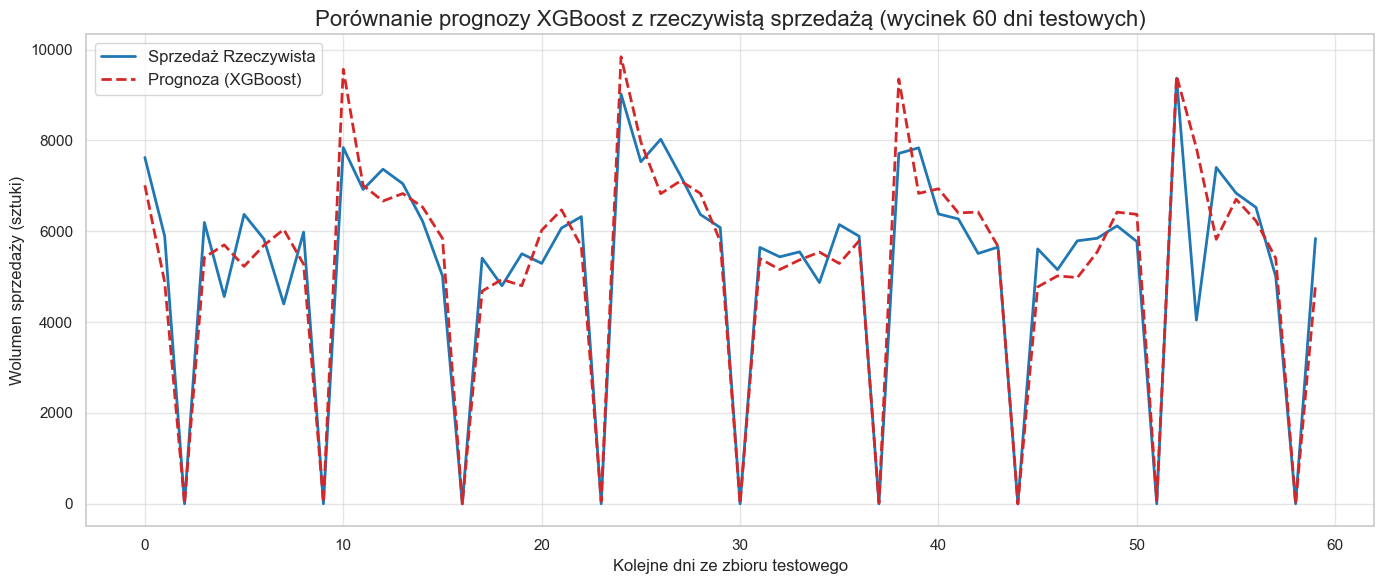

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

y_pred = xgb_preds

dni_do_wykresu = 60

plt.figure(figsize=(14, 6))

plt.plot(y_test.values[:dni_do_wykresu], label='Sprzedaż Rzeczywista', color='#1f77b4', linewidth=2)
plt.plot(y_pred[:dni_do_wykresu], label='Prognoza (XGBoost)', color='#d62728', linestyle='--', linewidth=2)

plt.title('Porównanie prognozy XGBoost z rzeczywistą sprzedażą (wycinek 60 dni testowych)', fontsize=16)
plt.xlabel('Kolejne dni ze zbioru testowego', fontsize=12)
plt.ylabel('Wolumen sprzedaży (sztuki)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.tight_layout()

plt.savefig('Prognoza_vs_Rzeczywistosc.png', dpi=300, bbox_inches='tight')
plt.show()

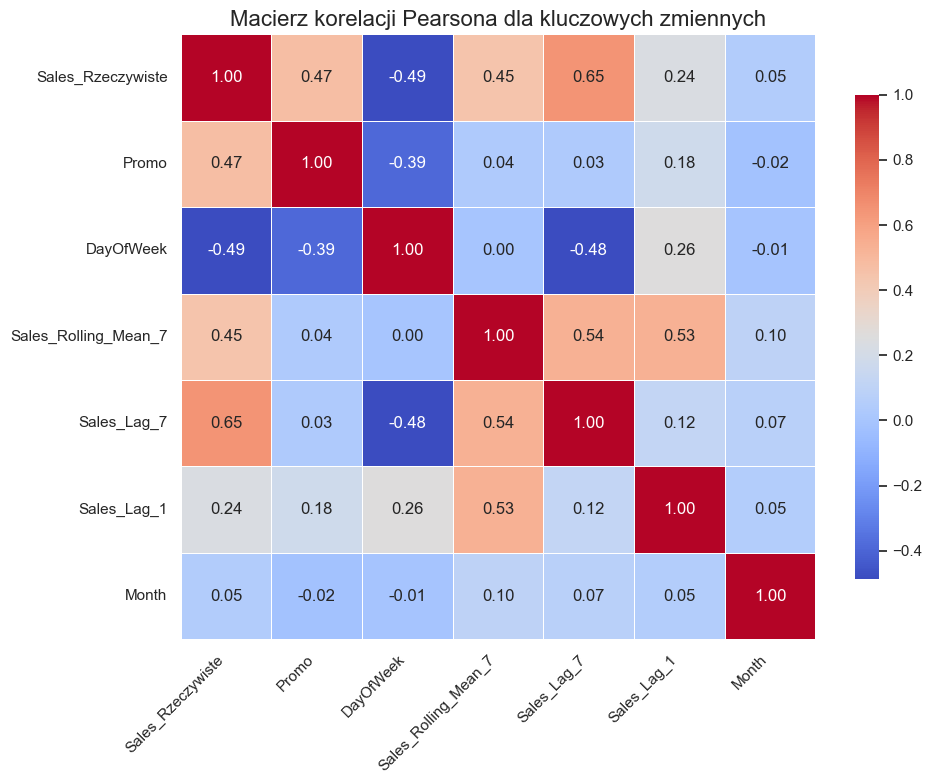

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = X_test.copy()
df_corr['Sales_Rzeczywiste'] = y_test.values

mozliwe_kolumny = ['Sales_Rzeczywiste', 'Promo', 'DayOfWeek', 'Sales_Rolling_Mean_7', 'Sales_Lag_7', 'Sales_Lag_1', 'Month']
kolumny_do_wykresu = [kol for kol in mozliwe_kolumny if kol in df_corr.columns]

plt.figure(figsize=(10, 8))

sns.heatmap(df_corr[kolumny_do_wykresu].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Macierz korelacji Pearsona dla kluczowych zmiennych', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('Macierz_Korelacji.png', dpi=300, bbox_inches='tight')
plt.show()

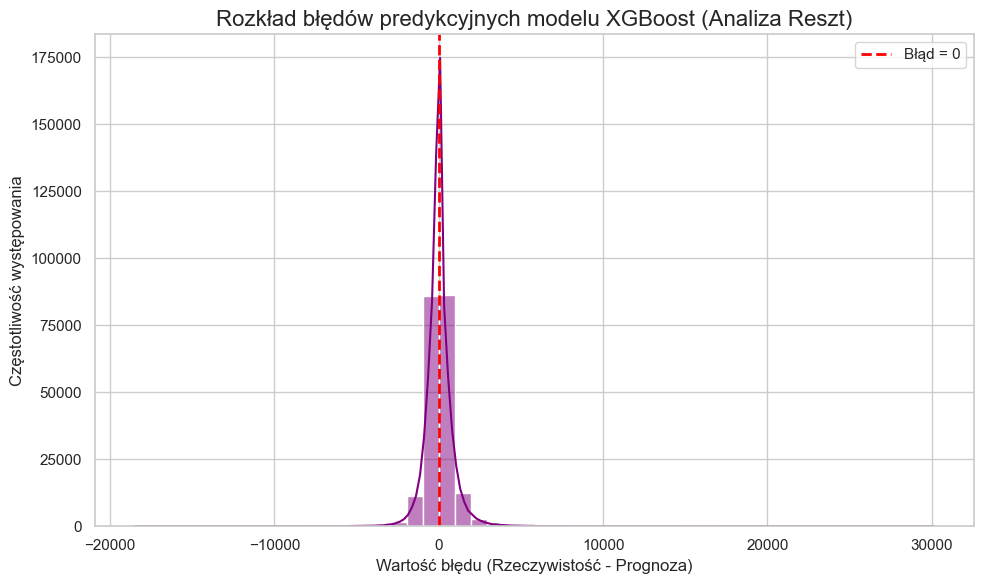

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = xgb_preds

reszty = y_test.values - y_pred

plt.figure(figsize=(10, 6))

sns.histplot(reszty, bins=50, kde=True, color='purple')

plt.title('Rozkład błędów predykcyjnych modelu XGBoost (Analiza Reszt)', fontsize=16)
plt.xlabel('Wartość błędu (Rzeczywistość - Prognoza)', fontsize=12)
plt.ylabel('Częstotliwość występowania', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Błąd = 0')
plt.legend()
plt.tight_layout()

plt.savefig('Analiza_Reszt.png', dpi=300, bbox_inches='tight')
plt.show()


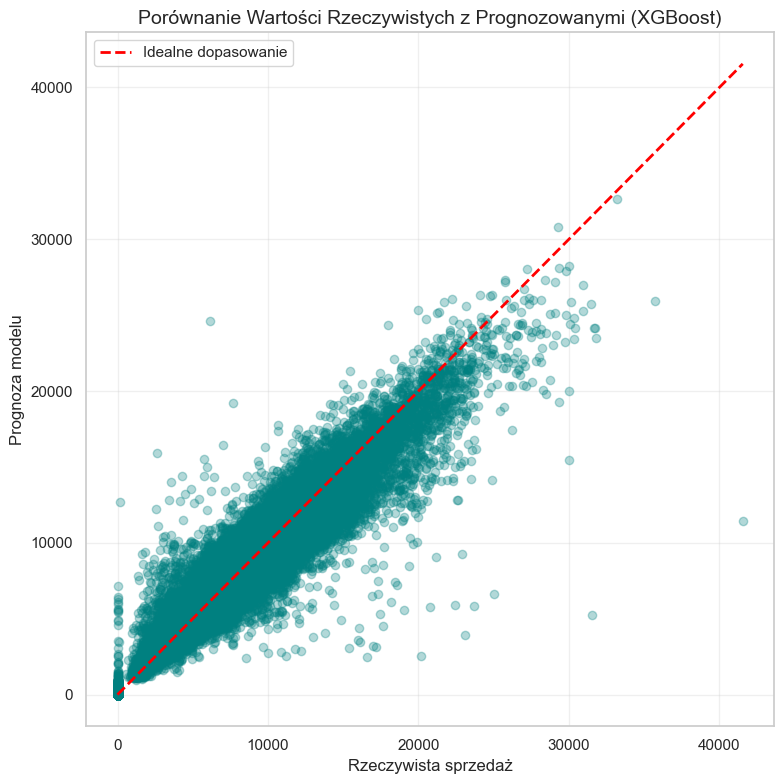

In [30]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = xgb_preds

plt.figure(figsize=(8, 8))
plt.scatter(y_test.values, y_pred, alpha=0.3, color='teal')

min_val = min(np.min(y_test.values), np.min(y_pred))
max_val = max(np.max(y_test.values), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Idealne dopasowanie')

plt.title('Porównanie Wartości Rzeczywistych z Prognozowanymi (XGBoost)', fontsize=14)
plt.xlabel('Rzeczywista sprzedaż', fontsize=12)
plt.ylabel('Prognoza modelu', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('Scatter_Prognoza.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import seaborn as sns
import sklearn
import xgboost as xgb

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", mpl.__version__)
print("Seaborn:", sns.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgb.__version__)

Pandas: 3.0.2
NumPy: 2.4.4
Matplotlib: 3.10.9
Seaborn: 0.13.2
Scikit-learn: 1.8.0
XGBoost: 3.2.0


In [32]:
!python --version

Python 3.12.3
